In [17]:
import sys
print(sys.executable)

c:\Users\NaiaA\OneDrive - Mondragon Unibertsitatea\Escritorio\RETO-5-NARANJA\reto5\Scripts\python.exe


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import seaborn as sns

X_train = pd.read_csv("X_train_prima.csv")
X_test = pd.read_csv("X_test_prima.csv")
y_train = pd.read_csv("y_train_prima.csv")
y_test = pd.read_csv("y_test_prima.csv")


In [19]:
#skelearn y statsmodel esperan una serie no un df
y_train = y_train["Prima"] if "Prima" in y_train.columns else y_train.iloc[:, 0]
y_test = y_test["Prima"] if "Prima" in y_test.columns else y_test.iloc[:, 0]

In [20]:
#las columnas despues de get dummys se guardan como bool en vez de numerico
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# modelo con sklearn + evaluar en test

In [21]:
modelo_sklearn = LinearRegression()
modelo_sklearn.fit(X=X_train, y=y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
def tabla_coeficientes(modelo: LinearRegression, nombres_features: list[str]) -> pd.DataFrame:
    coef_dict = {"intercepto": modelo.intercept_}
    for nombre, coef in zip(nombres_features, modelo.coef_):
        coef_dict[nombre] = coef
    return pd.DataFrame(list(coef_dict.items()), columns=["Feature", "Coeficiente"])


print(tabla_coeficientes(modelo_sklearn, list(X_train.columns)))
print("Coeficiente de determinacion R^2 (train):", modelo_sklearn.score(X_train, y_train))

                         Feature  Coeficiente
0                     intercepto   402.306362
1                   Num_Creditos     0.210617
2                  Monto_Inicial   108.547825
3                   Meses_Empleo     7.466156
4                       Duracion    83.238368
5             Scoring_Crediticio   -59.641325
6           Ratio_Deuda_Ingresos   114.305757
7                  Ratio_Interes    37.380965
8                           Edad     1.000750
9                       Ingresos    15.699239
10              Estudios_Escolar   -30.305768
11  Estudios_Grado Universitario   -14.489174
12               Estudios_Máster    -1.034764
13       Estado_Civil_Divorciado     3.354430
14          Estado_Civil_Soltero    -5.529318
Coeficiente de determinacion R^2 (train): 0.6927007798708061


In [23]:
predicciones_sklearn = modelo_sklearn.predict(X=X_test)
mse = mean_squared_error(y_true=y_test, y_pred=predicciones_sklearn)
rmse = root_mean_squared_error(y_true=y_test, y_pred=predicciones_sklearn)
mae = mean_absolute_error(y_true=y_test, y_pred=predicciones_sklearn)

print(f"Primeras cinco predicciones: {predicciones_sklearn[0:5]}")
print(f"El error (mse) de test es: {round(mse, 2)}")
print(f"El error (rmse) de test es: {round(rmse, 2)}")
print(f"El error (mae) de test es: {round(mae, 2)}")

Primeras cinco predicciones: [ 301.14398741  457.75295653  280.71828456 1025.48844557  195.66583236]
El error (mse) de test es: 22105.79
El error (rmse) de test es: 148.68
El error (mae) de test es: 117.8


# modelo con statsmodels

In [24]:
#resumen estadistico
X_train_sm = sm.add_constant(X_train, prepend=True)
modelo_sm = sm.OLS(endog=y_train, exog=X_train_sm)
modelo_sm = modelo_sm.fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Prima   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     9906.
Date:                Sat, 03 Oct 2026   Prob (F-statistic):               0.00
Time:                        10:53:39   Log-Likelihood:            -3.9495e+05
No. Observations:               61539   AIC:                         7.899e+05
Df Residuals:                   61524   BIC:                         7.901e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [25]:
#intervalos de confianza
intervalos_ci = modelo_sm.conf_int(alpha=0.05)
intervalos_ci.columns = ["2.5%", "97.5%"]
print(intervalos_ci)

                                    2.5%       97.5%
const                         396.123087  408.489638
Num_Creditos                   -0.960977    1.382210
Monto_Inicial                 106.867207  110.228443
Meses_Empleo                    2.784594   12.147718
Duracion                       82.066817   84.409918
Scoring_Crediticio            -60.842709  -58.439942
Ratio_Deuda_Ingresos          112.734933  115.876581
Ratio_Interes                  36.209399   38.552531
Edad                           -3.262158    5.263657
Ingresos                       13.345010   18.053468
Estudios_Escolar              -38.318921  -22.292615
Estudios_Grado Universitario  -20.698418   -8.279931
Estudios_Máster                -6.438132    4.368604
Estado_Civil_Divorciado         0.133764    6.575097
Estado_Civil_Soltero           -8.675242   -2.383393


# diagnostico de los residuos

C:\Users\NaiaA\AppData\Local\Temp\ipykernel_14896\3377573686.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],


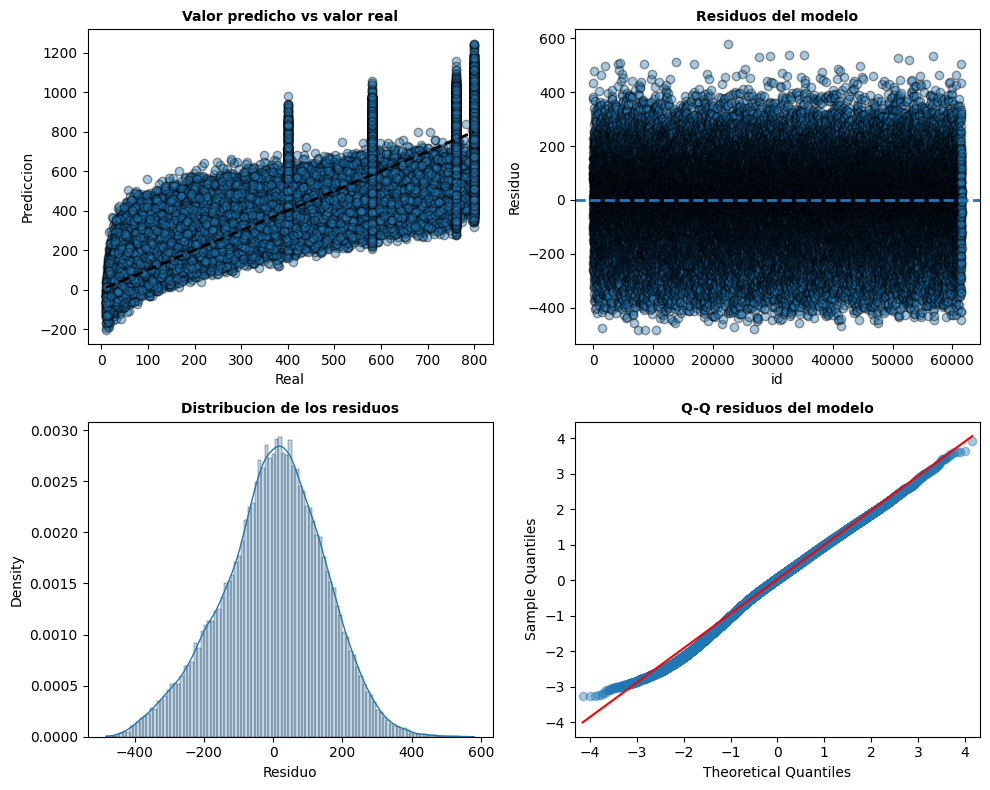

In [26]:
prediccion_train = modelo_sm.predict(exog=X_train_sm)
residuos_train = prediccion_train - y_train

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

axes[0, 0].scatter(y_train, prediccion_train, edgecolors=(0, 0, 0), alpha=0.4)
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
                "k--", color="black", lw=2)
axes[0, 0].set_title("Valor predicho vs valor real", fontsize=10, fontweight="bold")
axes[0, 0].set_xlabel("Real")
axes[0, 0].set_ylabel("Prediccion")

axes[0, 1].scatter(list(range(len(y_train))), residuos_train, edgecolors=(0, 0, 0), alpha=0.4)
axes[0, 1].axhline(y=0, linestyle="--", lw=2)
axes[0, 1].set_title("Residuos del modelo", fontsize=10, fontweight="bold")
axes[0, 1].set_xlabel("id")
axes[0, 1].set_ylabel("Residuo")

sns.histplot(data=residuos_train, stat="density", kde=True,
             line_kws={"linewidth": 1}, alpha=0.3, ax=axes[1, 0])
axes[1, 0].set_title("Distribucion de los residuos", fontsize=10, fontweight="bold")
axes[1, 0].set_xlabel("Residuo")

sm.qqplot(residuos_train, fit=True, line="q", ax=axes[1, 1], alpha=0.4, lw=2)
axes[1, 1].set_title("Q-Q residuos del modelo", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

# test de normalidad de los residuos

In [27]:
shapiro_test = stats.shapiro(residuos_train)
print("Shapiro-Wilk:", shapiro_test)

k2, p_value = stats.normaltest(residuos_train)
print(f"D'Agostino K^2: estadistico = {k2}, p-value = {p_value}")

Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.9961254562506756), pvalue=np.float64(3.6044833197739226e-35))
D'Agostino K^2: estadistico = 408.7750074437005, p-value = 1.720421905463416e-89


c:\Users\NaiaA\OneDrive - Mondragon Unibertsitatea\Escritorio\RETO-5-NARANJA\reto5\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 61539.
  res = hypotest_fun_out(*samples, **kwds)


# predicciones

In [28]:
predicciones_intervalo = modelo_sm.get_prediction(exog=X_train_sm).summary_frame(alpha=0.05)
print(predicciones_intervalo.head())

          mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0   311.742672  1.592290     308.621780     314.863564     21.113166   
1   377.442157  2.222468     373.086114     381.798200     86.796763   
2   371.671413  1.967672     367.814770     375.528055     81.033075   
3   221.208157  2.753795     215.810712     226.605602    -69.454710   
4  1014.100192  3.935028    1006.387527    1021.812858    723.385117   

   obs_ci_upper  
0    602.372178  
1    668.087551  
2    662.309751  
3    511.871024  
4   1304.815268  


# error del test

In [29]:
X_test_sm = sm.add_constant(X_test, prepend=True)
predicciones_test_sm = modelo_sm.predict(exog=X_test_sm)
rmse_test_sm = root_mean_squared_error(y_true=y_test, y_pred=predicciones_test_sm)
print(f"El error (rmse) de test (statsmodels) es: {round(rmse_test_sm, 2)}")

El error (rmse) de test (statsmodels) es: 148.68
